# Working with Seismic Data Tutorial  

This notebook details the seismic inspection and preprocessing tools and methods available through seismicwind.py



## 0. Imports and Setup

In [38]:
# For Configuration File
import yaml
from pathlib import Path
import importlib

config_path = 'C:\\Users\\simon\\Desktop\\UTAS\\Honours Research\\GitHub\\seismic-weather\\config.yaml'

# Load Config File
with open(config_path, "r") as f:
    config = yaml.safe_load(f)

# Config Variables
name = config["name"]
seismic_path = config["seismic_data_path"]
seismic_data = Path(config['seismic_data_path'])
aws_path = config['aws_data_path']
seiswind_module = config['seiswind_module']

# obspy GitHub:
# https://github.com/obspy/obspy
from obspy import UTCDateTime as UTC

# seismic-weather GitHub:
# https://github.com/Ramirezs873/seismic-weather
spec = importlib.util.spec_from_file_location("seismicwind", seiswind_module)
seismicwind = importlib.util.module_from_spec(spec)
spec.loader.exec_module(seismicwind)

In [39]:
# Load class Seismic
## Load with config file
seis = seismicwind.Seismic(config=config)

## 1. Load Seismic Data

To gather seismic data, call get_seis() in the Seismic class.

get_seis() retrieves seismic data from a sensor through an FDSN client for the given specifications and saves it as an mseed file. If The data has previously been stored locally, then the function instead opens the file.


In [40]:
# Gather Data
## Station CASY used as an example
data = seis.get_seis(client = 'IRIS',
                     network = 'IU',
                     station = 'CASY',
                     location = '00',
                     channel = 'BH?',
                     t_start = UTC(2022, 12, 24, 23, 0,0),
                     t_end = UTC(2023, 1, 1, 1, 1, 0),
                     username = None,
                     password = None,
                     file_name = 'CASY_2022_Christmas')

Reading existing file: C:\Users\simon\Desktop\UTAS\Honours Research\Workspace\CASY_2022_Christmas.mseed


The waveform data can then be viewed as a dictionary via data.st

In [41]:
data.st

defaultdict(list,
            {'IU.CASY.00': [IU.CASY.00.BH1 | 2022-12-24T23:00:00.019538Z - 2023-01-01T01:00:59.969538Z | 20.0 Hz, 12241200 samples,
              IU.CASY.00.BH2 | 2022-12-24T23:00:00.019539Z - 2023-01-01T01:00:59.969539Z | 20.0 Hz, 12241200 samples,
              IU.CASY.00.BHZ | 2022-12-24T23:00:00.019539Z - 2023-01-01T01:00:59.969539Z | 20.0 Hz, 12241200 samples]})

To save the waveform stream information at each step, ensure .st.copy() is used

In [42]:
data_original = data.st.copy()

## 2. Plotting Waveforms

Using the analysis subclass Seismic().analysis, the function plot_streams() helps to visualise the waveforms.

plot_streams() plots the waveform time series for all of the channels gathered for the station.

Plotting IU.CASY.00


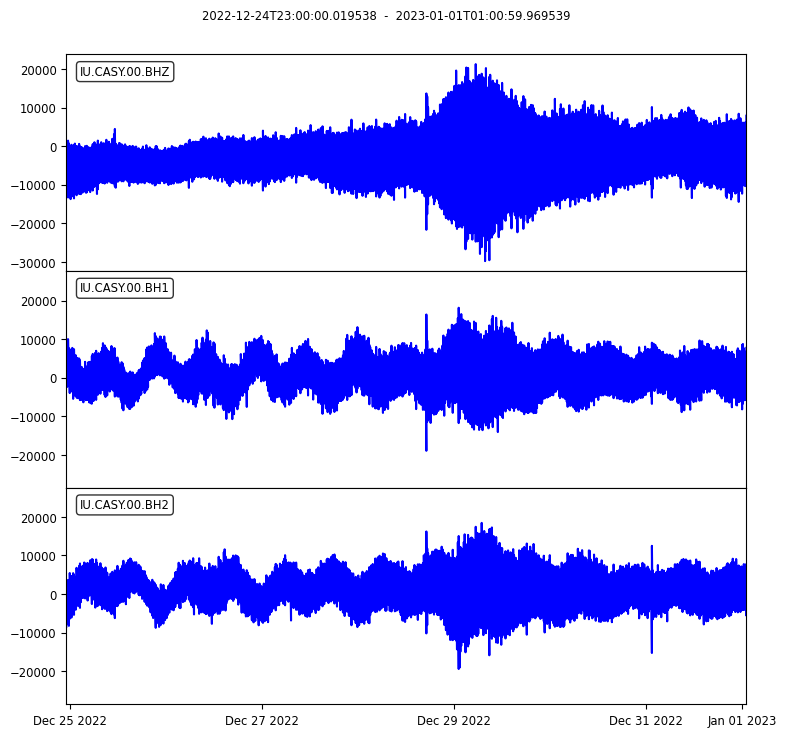

In [43]:
data.analysis.plot_streams(color = 'blue')

## 3. Seismic Preprocessing

Using the preprocess subclass Seismic().preprocess, waveform preprocessing can be applied.

For this tutoring, plot_streams() and .st will not be used going on, but feel free to try it after each step to assist further, e.g. trim.analysis.plot_streams(), trim.st

### 3.1 Selecting a Time Window

The function trim() is used to select a specfic time window of the data's time series. 

In [44]:
trim = data.preprocess.trim(t_start = UTC(2022, 12, 25, 1, 0,0),
                            duration = 3600, # in seconds
                            save_mseed = False,
                            file_name = 'CASY_trim')

### 3.2 Demeaning 

The function demean() is used to demean the waveform.

In [45]:
demean = data.preprocess.demean(save_mseed = False,
                                file_name = 'CASY_demean')

### 3.3 Detrending

The function detrend() is used to detrend the waveform.

In [46]:
detrend = data.preprocess.detrend(save_mseed = False,
                                    file_name = 'CASY_detrend')

### 3.4 Window Function

The function window() applies a window function to the waveform.

In [50]:
window = data.preprocess.window(type = 'hann',
                                max_percentage = 30,
                                max_length = None, 
                                side = 'both',
                                save_mseed=False,
                                file_name='default_window')

c:\Users\simon\anaconda3\envs\seismic\Lib\site-packages\obspy\core\trace.py:2155: UserWarning: The requested taper is longer than the trace. The taper will be shortened to trace length.
  warnings.warn(msg)


### 3.5 Filter Function

The function filter() applies a frequency filter to the waveform.

In [59]:
filt = data.preprocess.filter(filter_type = 'bandpass', 
                              freqmin=5, 
                              freqmax=9, 
                              freq=None, 
                              corners=4, 
                              zerophase=True,
                              save_mseed=False,
                              file_name='default_filter')

### 3.6 Amplitude Correction

The function amp_correction() applies amplitude correction to the waveforms of each of the station channels.

This function also corrects for instrument sensitivity before applying the amplitude correction.

In [65]:
amp = data.preprocess.amp_correction(NS_channel=['BH1'],
                                     EW_channel=['BH2'],
                                     Z_channel=['BHZ'],
                                     sensitivity = 3.35882E9, # CASY sensitivity
                                     NS_correction_factor=[1/0.1], # Random corrections
                                     EW_correction_factor=[1/0.2],
                                     Z_correction_factor=[1/0.1],
                                     save_mseed=False,
                                     file_name='default_amp_corr')

Processing IU.CASY.00...


### 3.7 Rotation Correction

The function rotate() rotates the seismic waveforms of the horizontal components.

In [ ]:
rot = data.preprocess.rotate(NS_channel=['BH1'],
                             EW_channel=['BH2'],
                             Z_channel=['BHZ'],
                             misalignment_angle = [-40],
                             save_mseed=False,
                             file_name='default_rotate')

Processing IU.CASY.00...
